In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [5]:
columns = ['unit_nr', 'time_cycles']
columns += [f'op_setting_{i}' for i in range(1, 4)]
columns += [f'sensor_{i}' for i in range(1, 22)]

print(columns)
print("Total columns:", len(columns))

['unit_nr', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Total columns: 26


In [6]:
train_df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]
test_df = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]
rul_df = pd.read_csv("RUL_FD001.txt", header=None, names=["RUL"])

train_df.columns = columns
test_df.columns = columns

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
print("Train info:")
print(train_df.info())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nNumber of train engines:", train_df['unit_nr'].nunique())
print("Number of test engines:", test_df['unit_nr'].nunique())

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_nr       20631 non-null  int64  
 1   time_cycles   20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     

In [8]:
max_cycle_train = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle_train.columns = ['unit_nr', 'max_cycle']

train_df = train_df.merge(max_cycle_train, on='unit_nr', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

train_df[['unit_nr', 'time_cycles', 'RUL']].head(10)

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [9]:
train_last = train_df.groupby('unit_nr').tail(1)[['unit_nr','time_cycles','RUL']]
train_last.head(10)

,unit_nr,time_cycles,RUL
191,1,192,0
478,2,287,0
657,3,179,0
846,4,189,0
1115,5,269,0
1303,6,188,0
1562,7,259,0
1712,8,150,0
1913,9,201,0
2135,10,222,0


In [10]:
max_cycle_test = test_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle_test.columns = ['unit_nr','max_cycle']

rul_df['unit_nr'] = rul_df.index + 1

test_truth = max_cycle_test.merge(rul_df, on='unit_nr')
test_truth['failure_cycle'] = test_truth['max_cycle'] + test_truth['RUL']

test_df = test_df.merge(test_truth[['unit_nr','failure_cycle']], on='unit_nr')
test_df['RUL'] = test_df['failure_cycle'] - test_df['time_cycles']

test_df.drop(columns=['failure_cycle'], inplace=True)

test_df[['unit_nr','time_cycles','RUL']].head(10)

,unit_nr,time_cycles,RUL
0,1,1,142
1,1,2,141
2,1,3,140
3,1,4,139
4,1,5,138
5,1,6,137
6,1,7,136
7,1,8,135
8,1,9,134
9,1,10,133


In [11]:
feature_cols = [col for col in train_df.columns if col not in ['unit_nr','time_cycles','RUL']]

print("Total features:", len(feature_cols))
feature_cols[:10]

Total features: 24


['op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7']

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

train_df.head()

,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187


In [13]:
MAX_RUL = 125

train_df['RUL'] = train_df['RUL'].clip(upper=MAX_RUL)
test_df['RUL'] = test_df['RUL'].clip(upper=MAX_RUL)

print("Max Train RUL:", train_df['RUL'].max())

Max Train RUL: 125


In [14]:
def create_sequences(df, feature_cols, seq_len=30):
    X = []
    y = []

    for unit in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit].reset_index(drop=True)

        for i in range(len(unit_data) - seq_len + 1):
            X.append(unit_data.loc[i:i+seq_len-1, feature_cols].values)
            y.append(unit_data.loc[i+seq_len-1, 'RUL'])

    return np.array(X), np.array(y)

In [15]:
SEQ_LEN = 30

X_train, y_train = create_sequences(train_df, feature_cols, SEQ_LEN)
X_test, y_test = create_sequences(test_df, feature_cols, SEQ_LEN)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (17731, 30, 24)
y_train: (17731,)
X_test: (10196, 30, 24)
y_test: (10196,)


In [16]:
print("Sample sequence shape:", X_train[0].shape)
print("Sample target:", y_train[0])

Sample sequence shape: (30, 24)
Sample target: 125


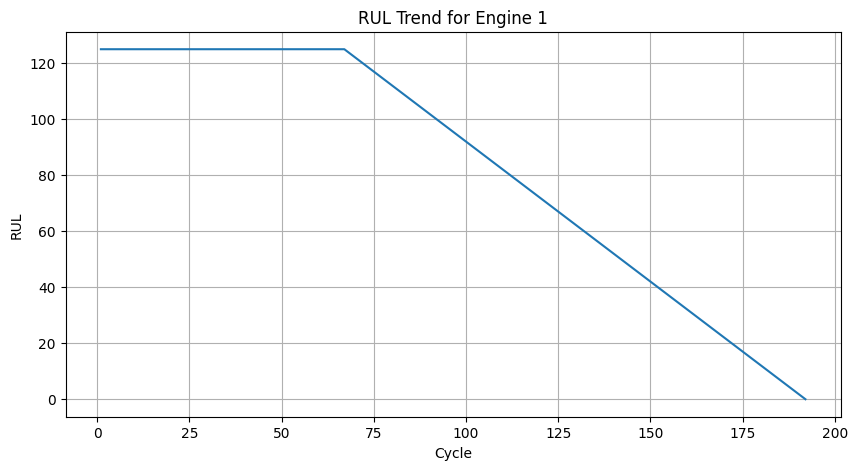

In [17]:
engine_1 = train_df[train_df['unit_nr'] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_1['time_cycles'], engine_1['RUL'])
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL Trend for Engine 1")
plt.grid(True)
plt.show()

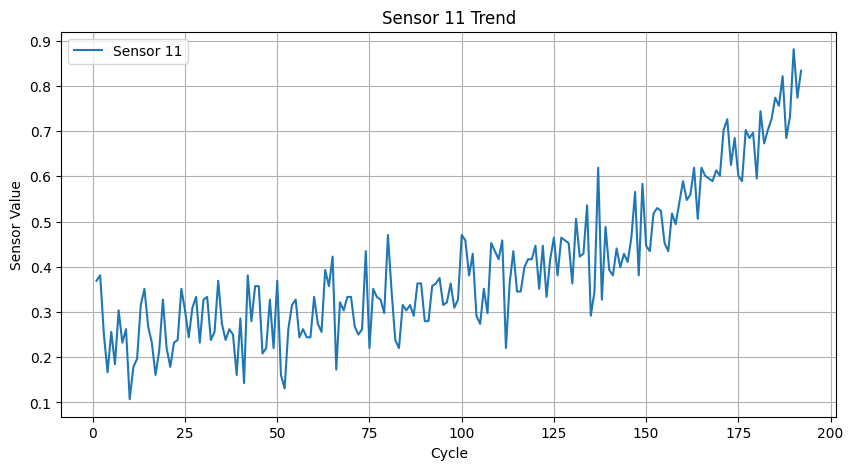

In [18]:
plt.figure(figsize=(10,5))
plt.plot(engine_1['time_cycles'], engine_1['sensor_11'], label="Sensor 11")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor 11 Trend")
plt.legend()
plt.grid(True)
plt.show()

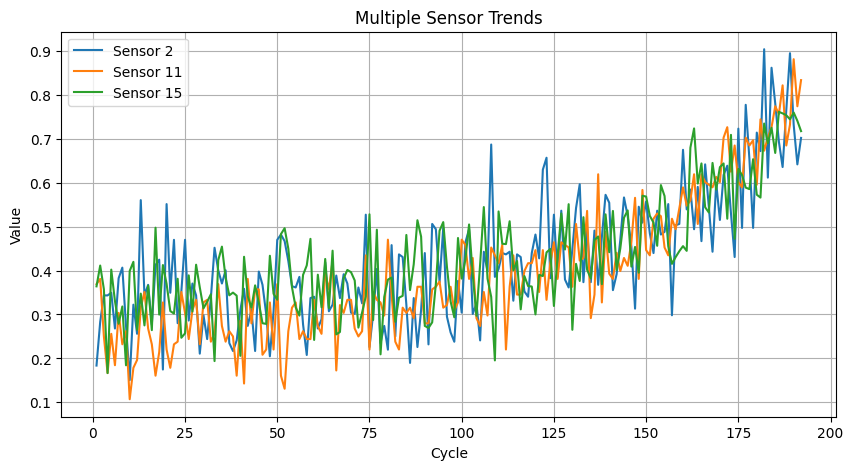

In [19]:
plt.figure(figsize=(10,5))
plt.plot(engine_1['time_cycles'], engine_1['sensor_2'], label="Sensor 2")
plt.plot(engine_1['time_cycles'], engine_1['sensor_11'], label="Sensor 11")
plt.plot(engine_1['time_cycles'], engine_1['sensor_15'], label="Sensor 15")

plt.xlabel("Cycle")
plt.ylabel("Value")
plt.title("Multiple Sensor Trends")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)

np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

print("Saved successfully")

Saved successfully


In [21]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17731, 30, 24)
y_train shape: (17731,)
X_test shape: (10196, 30, 24)
y_test shape: (10196,)


In [22]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (17731, 720)
X_test_flat shape: (10196, 720)


In [23]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=42
)

print("Train split:", X_tr.shape, y_tr.shape)
print("Validation split:", X_val.shape, y_val.shape)

Train split: (14184, 720) (14184,)
Validation split: (3547, 720) (3547,)


In [26]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

baseline_model.fit(X_tr, y_tr)

print("Baseline model training completed.")

Baseline model training completed.


In [27]:
y_val_pred = baseline_model.predict(X_val)

print("First 10 validation predictions:")
print(y_val_pred[:10])

First 10 validation predictions:
[ 73.73961429 108.51282686 122.12363974 118.13327758  96.2818653
  82.89024269  47.15872606 121.30421765  24.24721607  60.04429688]


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)
print("Validation R2 Score:", val_r2)

Validation RMSE: 18.30675216124422
Validation MAE: 14.009292396745328
Validation R2 Score: 0.806611717463176


In [29]:
y_test_pred = baseline_model.predict(X_test_flat)

print("First 10 test predictions:")
print(y_test_pred[:10])

First 10 test predictions:
[114.13230034 115.97429036 112.33937915 112.86470275 108.42235536
 109.72822678 113.4349169  112.42913747 111.71804227 111.27680818]


In [30]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R2 Score:", test_r2)

Test RMSE: 17.90243905129575
Test MAE: 13.88760450690998
Test R2 Score: 0.6373049615909707


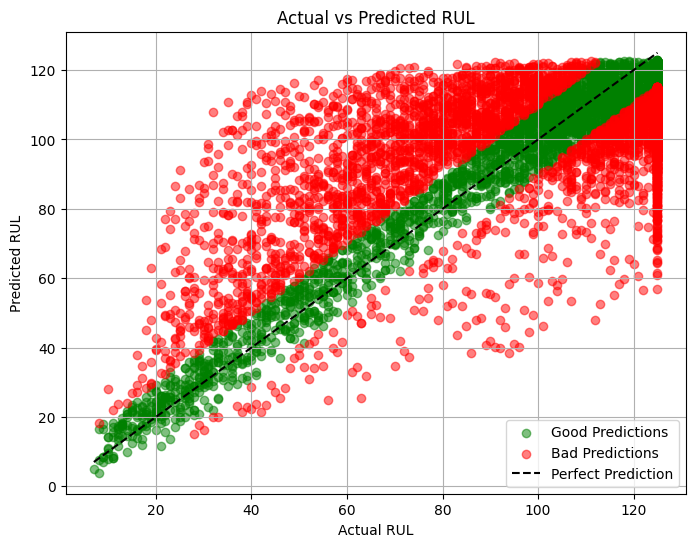

In [37]:
threshold = 10  # error threshold

good = abs(y_test - y_test_pred) <= threshold
bad = abs(y_test - y_test_pred) > threshold

plt.figure(figsize=(8, 6))

plt.scatter(y_test[good], y_test_pred[good], color='green', alpha=0.5, label="Good Predictions")
plt.scatter(y_test[bad], y_test_pred[bad], color='red', alpha=0.5, label="Bad Predictions")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='black', label="Perfect Prediction")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.legend()
plt.grid(True)

plt.show()

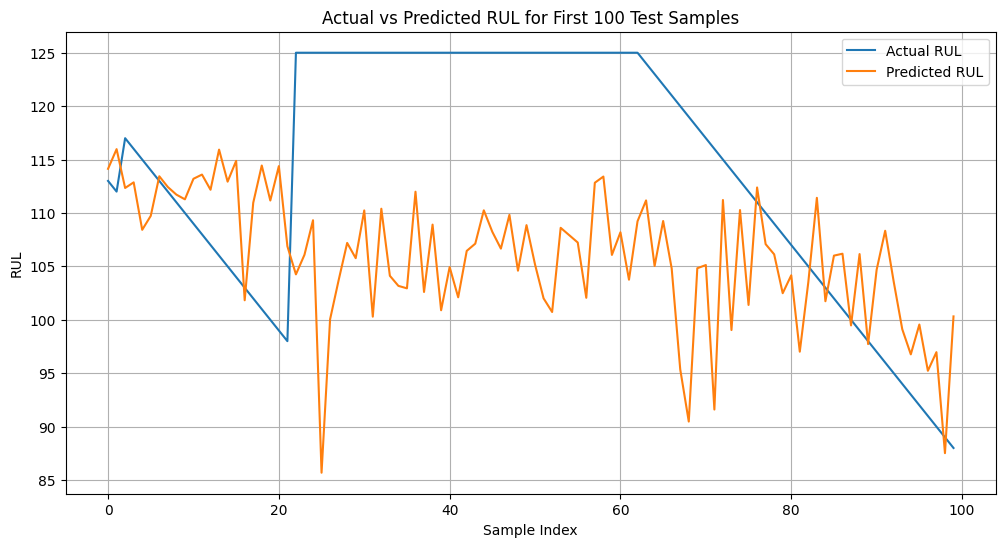

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label="Actual RUL")
plt.plot(y_test_pred[:100], label="Predicted RUL")
plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.title("Actual vs Predicted RUL for First 100 Test Samples")
plt.legend()
plt.grid(True)
plt.show()

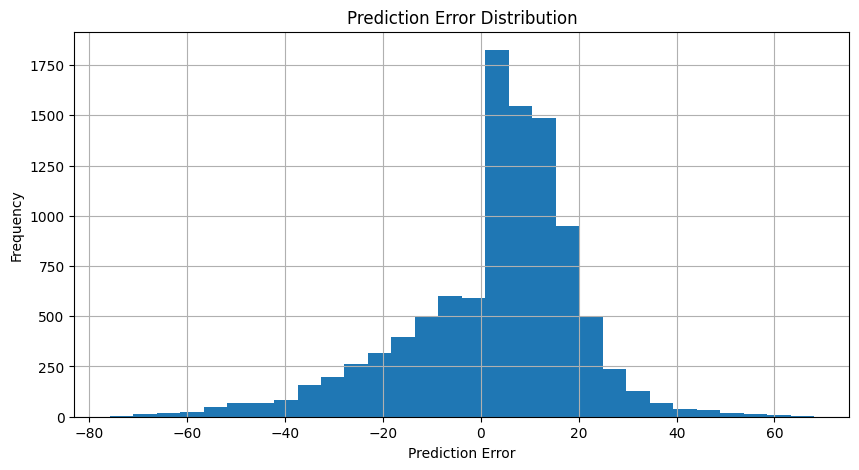

In [38]:
errors = y_test - y_test_pred

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.grid(True)
plt.show()

In [39]:
results_df = pd.DataFrame({
    "Actual_RUL": y_test,
    "Predicted_RUL": y_test_pred,
    "Error": y_test - y_test_pred
})

results_df.to_csv("baseline_model_test_results.csv", index=False)

print("Results saved successfully.")
results_df.head()

Results saved successfully.


,Actual_RUL,Predicted_RUL,Error
0,113,114.132300,-1.132300
1,112,115.974290,-3.974290
2,117,112.339379,4.660621
3,116,112.864703,3.135297
4,115,108.422355,6.577645


In [40]:
print("Milestone 2 Completed")
print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)
print("Validation R2:", val_r2)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)

Milestone 2 Completed
Validation RMSE: 18.30675216124422
Validation MAE: 14.009292396745328
Validation R2: 0.806611717463176
Test RMSE: 17.90243905129575
Test MAE: 13.88760450690998
Test R2: 0.6373049615909707
